# Online Shoppers Purchasing Intention: Week 2 (Load + EDA)

**Business question:** which session behaviours predict a purchase (`Revenue`)?

**Data:** Sakar, C. and Kastro, Y. (2018) *Online Shoppers Purchasing Intention Dataset*. UCI ML Repository. https://doi.org/10.24432/C5F88Q (CC BY 4.0)

## 1. Imports and settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Load data

In [2]:
DATA_PATH = '../data/raw/online_shoppers_intention.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Structure: shape, types, missing values, duplicates\n*Why:* confirms what we are working with and what cleaning is needed.

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (12330, 18)
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType   

In [4]:
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Duplicate rows: 125


## 4. Summary statistics\n*Why:* mean, std and quartiles show scale differences (needed for scaling) and skew/outliers.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [6]:
# Variance explicitly (brief asks for central tendency + spread)
num_cols = df.select_dtypes(include='number').columns
pd.DataFrame({'mean': df[num_cols].mean(), 'median': df[num_cols].median(),
              'variance': df[num_cols].var(), 'std': df[num_cols].std()})

,mean,median,variance,std
Administrative,2.315166,1.000000,1.103425e+01,3.321784
Administrative_Duration,80.818611,7.500000,3.125085e+04,176.779107
Informational,0.503569,0.000000,1.613297e+00,1.270156
Informational_Duration,34.472398,0.000000,1.981036e+04,140.749294
ProductRelated,31.731468,18.000000,1.978070e+03,44.475503
ProductRelated_Duration,1194.746220,598.936905,3.662130e+06,1913.669288
BounceRates,0.022191,0.003112,2.351117e-03,0.048488
ExitRates,0.043073,0.025156,2.361624e-03,0.048597
PageValues,5.889258,0.000000,3.447868e+02,18.568437
SpecialDay,0.061427,0.000000,3.956808e-02,0.198917


## 5. Target distribution\n*Why:* class imbalance decides which metrics and sampling strategy we justify later.

Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64


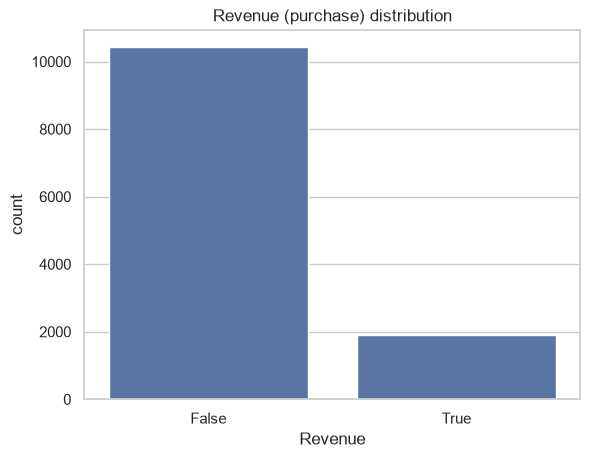

In [7]:
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True).round(3))
sns.countplot(x='Revenue', data=df)
plt.title('Revenue (purchase) distribution')
plt.show()

## 6. Categorical features vs target\n*Why:* shows which groups convert more.

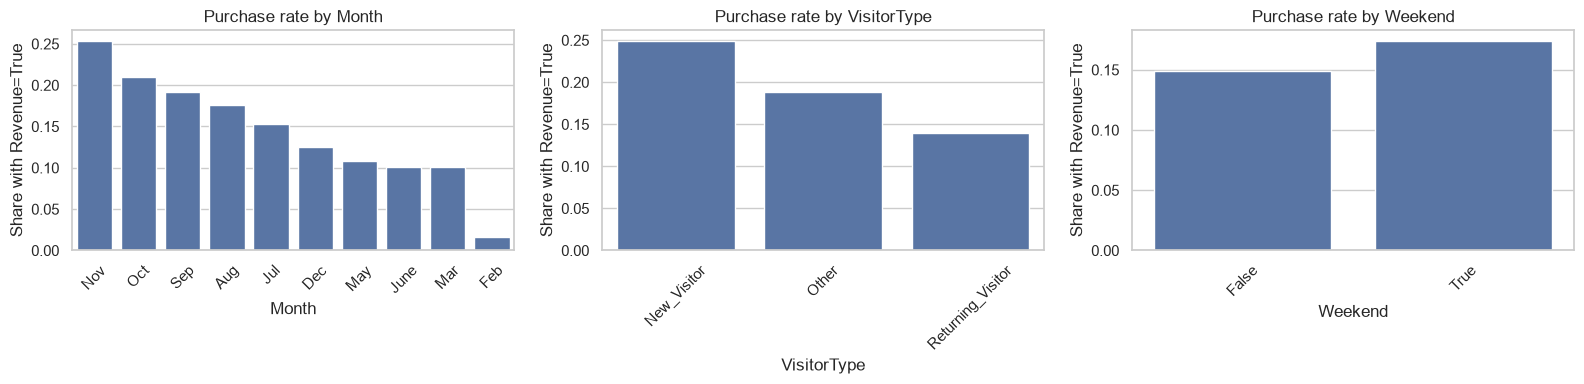

['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


In [8]:
cat_cols = ['Month', 'VisitorType', 'Weekend']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    rate = df.groupby(col)['Revenue'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f'Purchase rate by {col}')
    ax.set_ylabel('Share with Revenue=True')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(sorted(df['Month'].unique()))  # note: check naming (e.g. 'June' vs 'Jun') and missing months

## 7. Distributions of numeric features\n*Why:* the duration/count columns are usually heavily right-skewed; this motivates log transform or scaling.

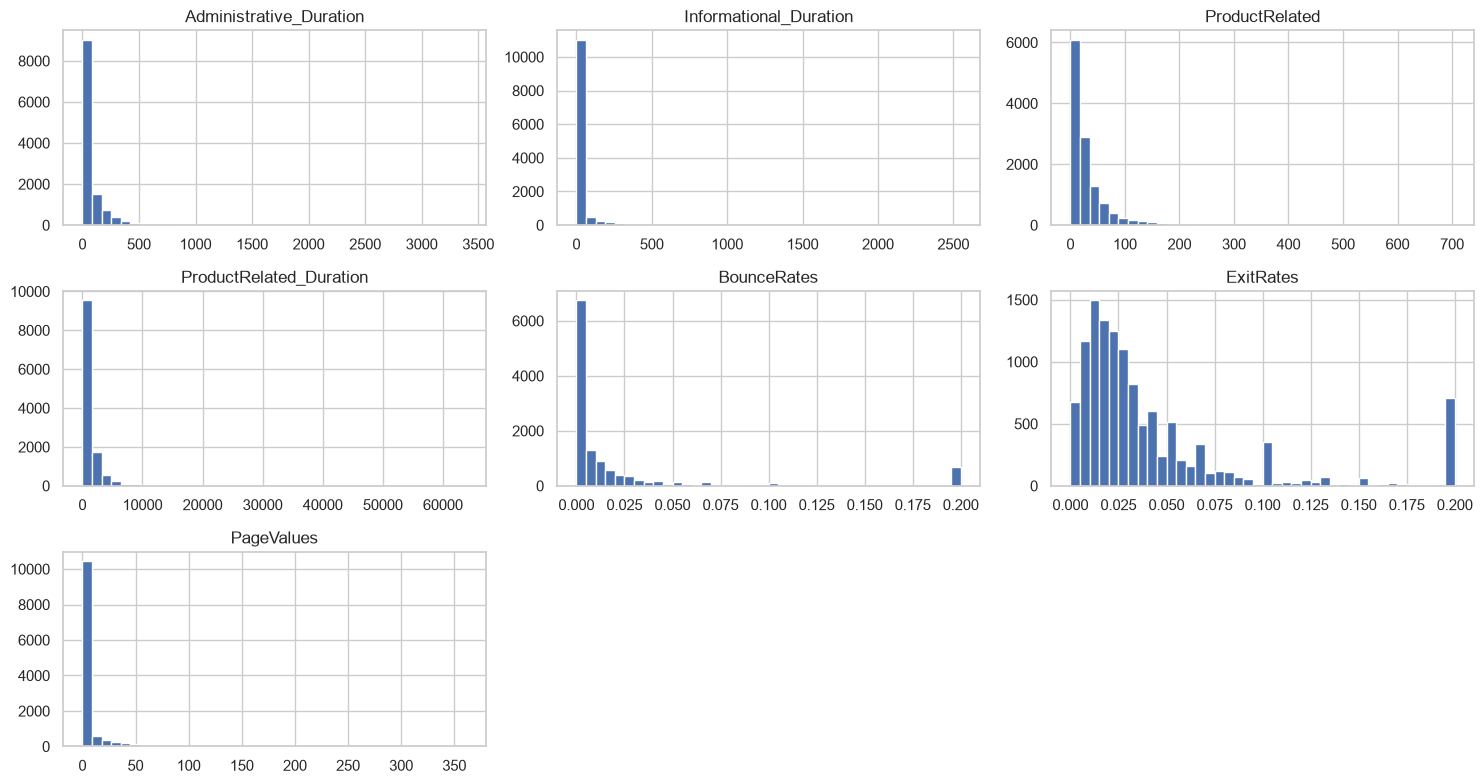

In [9]:
num_plot = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated',
            'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
df[num_plot].hist(bins=40, figsize=(15, 8))
plt.tight_layout(); plt.show()

## 8. Outliers (box plots by target)\n*Why:* decide whether to cap, transform or keep outliers.

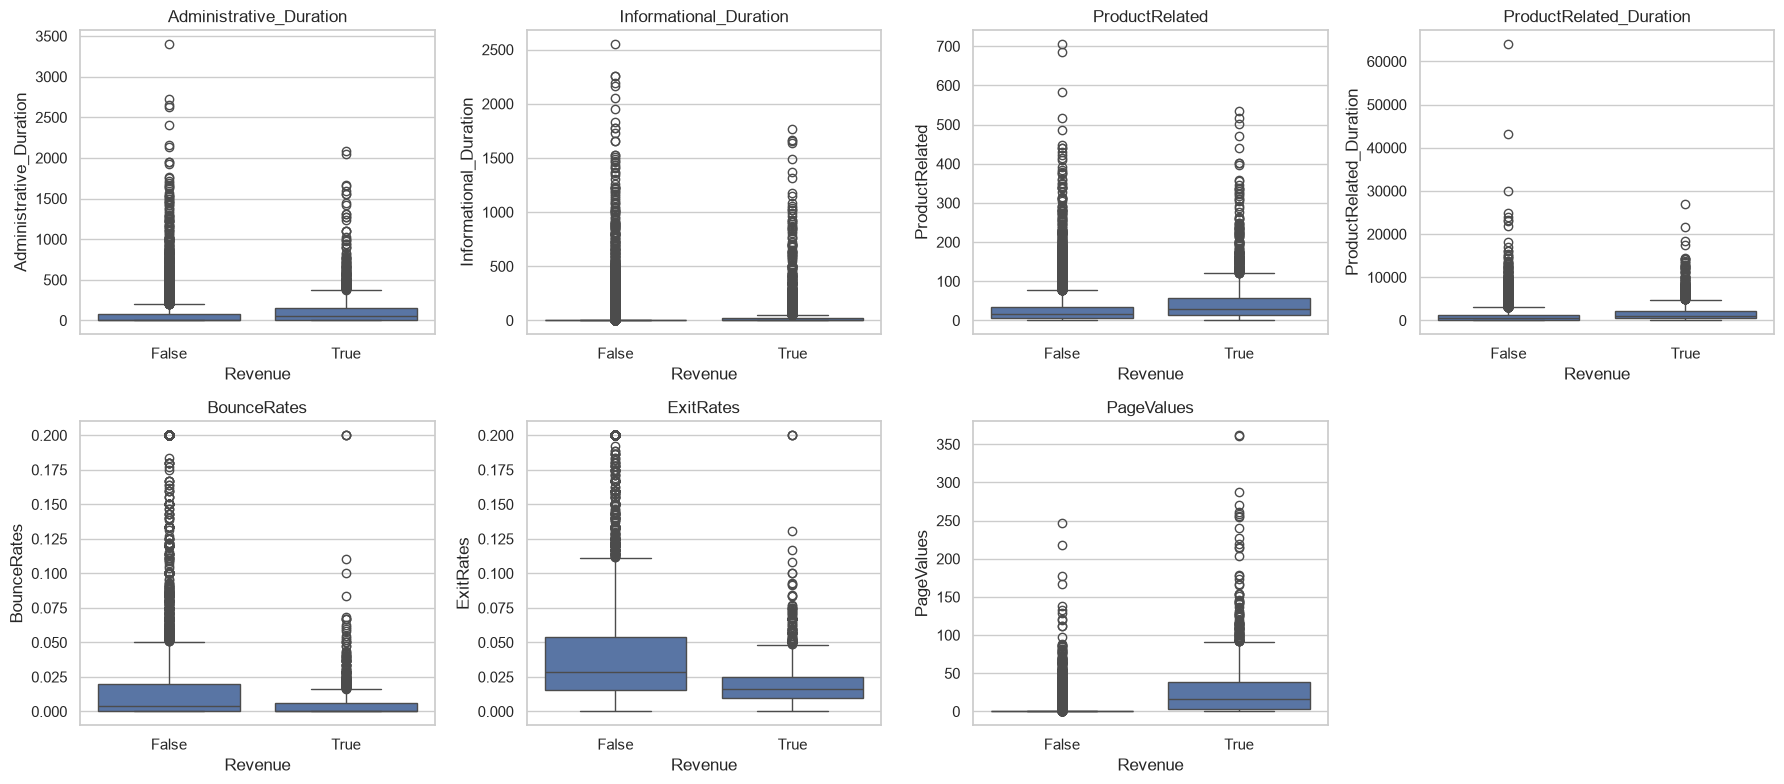

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), num_plot):
    sns.boxplot(x='Revenue', y=col, data=df, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

## 9. Correlation matrix\n*Why:* finds redundant features (e.g. BounceRates vs ExitRates) and the strongest links to Revenue.

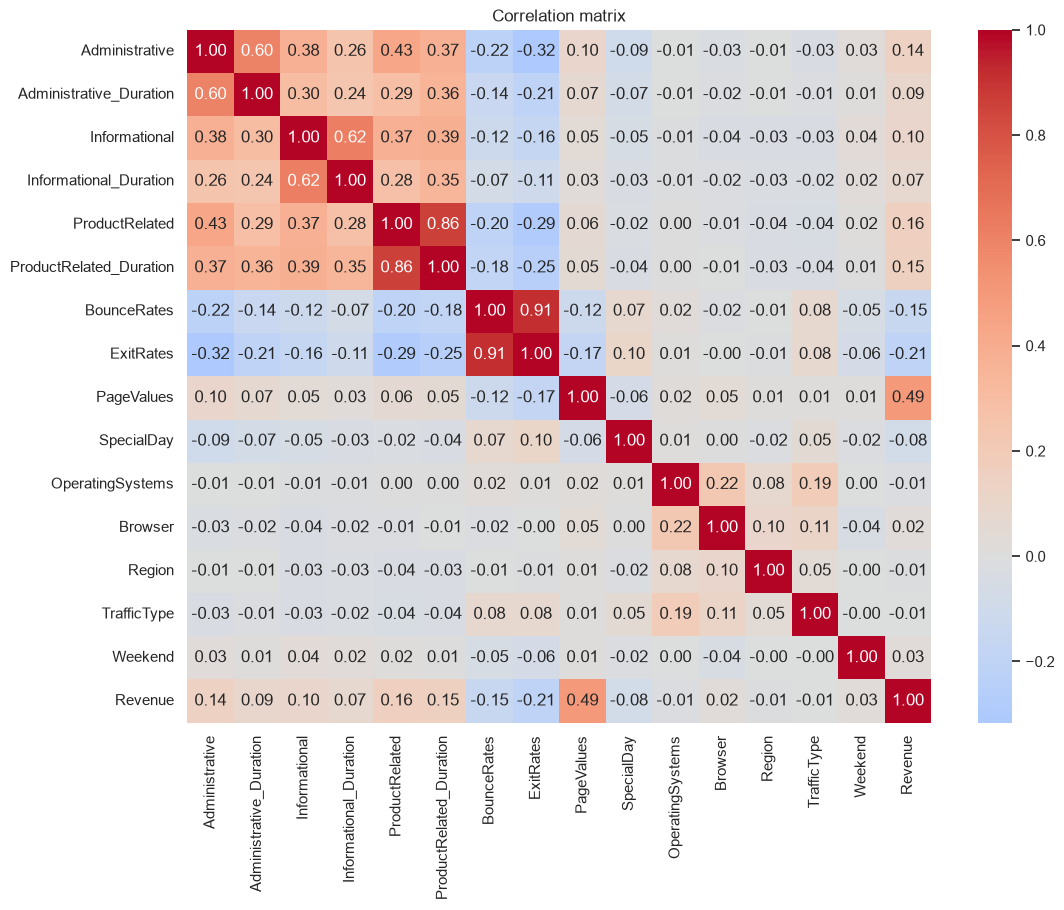

PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

In [11]:
corr = df.select_dtypes(include=['number', 'bool']).astype(float).corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()
corr['Revenue'].drop('Revenue').sort_values(ascending=False)

## 10. Scatter plot: engagement vs PageValues\n*Why:* `PageValues` is the strongest predictor; check how it relates to other behaviour.

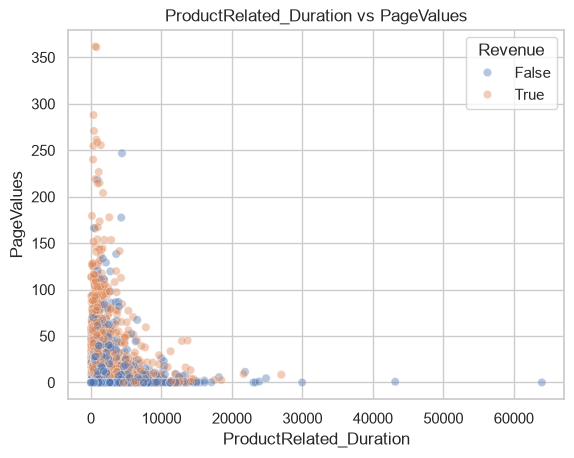

In [12]:
sns.scatterplot(data=df, x='ProductRelated_Duration', y='PageValues', hue='Revenue', alpha=0.4)
plt.title('ProductRelated_Duration vs PageValues')
plt.show()

## 11. EDA findings (fill in after running)\n- Class imbalance:\n- Duplicates:\n- Skew / outliers:\n- Strongest correlations:\n- Month / VisitorType effects:\n- Data quality issues to fix in Week 3: